In [1]:
#importing libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import random

2025-05-21 12:10:19.282392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747829419.536464      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747829419.614631      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Paths
base_dir = 'drive/MyDrive/FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Data Generator
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Image size and batch
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load Train & Validation
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

# Load Test Data
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 25919 images belonging to 3 classes.
Found 6479 images belonging to 3 classes.
Found 10500 images belonging to 3 classes.


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# Input shape
IMG_SHAPE = (224, 224, 3)

# Load the base MobileNetV2 model without the top layers
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=IMG_SHAPE)
base_model.trainable = False  # Freeze base layers for initial training

# Add custom classification head
inputs = Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

mobilenetv2_model = Model(inputs, outputs)

# Compile the model
mobilenetv2_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary of the model
mobilenetv2_model.summary()

# Train the model (initial training phase with frozen base)
history_mobilenet = mobilenetv2_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

2025-05-21 12:10:57.341682: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 834s 1s/step - accuracy: 0.8161 - loss: 0.4597 - val_accuracy: 0.9498 - val_loss: 0.1787
Epoch 2/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 832s 1s/step - accuracy: 0.9569 - loss: 0.1348 - val_accuracy: 0.9571 - val_loss: 0.1561
Epoch 3/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.9681 - loss: 0.1039 - val_accuracy: 0.9594 - val_loss: 0.1467
Epoch 4/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 879s 1s/step - accuracy: 0.9727 - loss: 0.0870 - val_accuracy: 0.9600 - val_loss: 0.1377
Epoch 5/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 837s 1s/step - accuracy: 0.9741 - loss: 0.0848 - val_accuracy: 0.9616 - val_loss: 0.1369
Epoch 6/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.9777 - loss: 0.0713 - val_accuracy: 0.9630 - val_loss: 0.1397
Epoch 7/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 883s 1s/step - accuracy: 0.9774 - loss: 0.0722 - val_accuracy: 0.9637 - val_loss: 0.1289
Epoch 8/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 946s 1s/step - accuracy: 0.9788 - loss: 0.0642 - val_accu

In [4]:
# Evaluate on the test set
test_loss, test_acc = mobilenetv2_model.evaluate(test_data)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")
print(f"🧪 Test Loss: {test_loss:.4f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 280s 849ms/step - accuracy: 0.9818 - loss: 0.0651

✅ Test Accuracy: 97.98%
🧪 Test Loss: 0.0749


In [5]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.utils import to_categorical

# Predict probabilities
y_probs = mobilenetv2_model.predict(test_data)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_data.classes

# For ROC-AUC
y_true_categorical = to_categorical(y_true, num_classes=3)

329/329 ━━━━━━━━━━━━━━━━━━━━ 311s 938ms/step


📄 Classification Report:
              precision    recall  f1-score   support

       Smoke       0.99      0.98      0.98      3500
        fire       0.98      0.97      0.97      3500
    non fire       0.98      0.98      0.98      3500

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500



<Figure size 600x500 with 0 Axes>

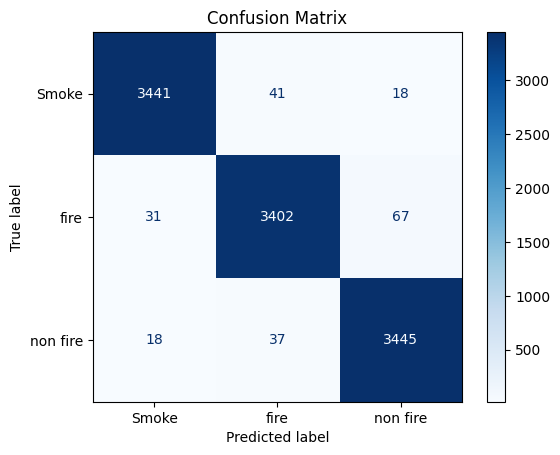

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

# Classification report
print("📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=test_data.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.class_indices.keys())

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


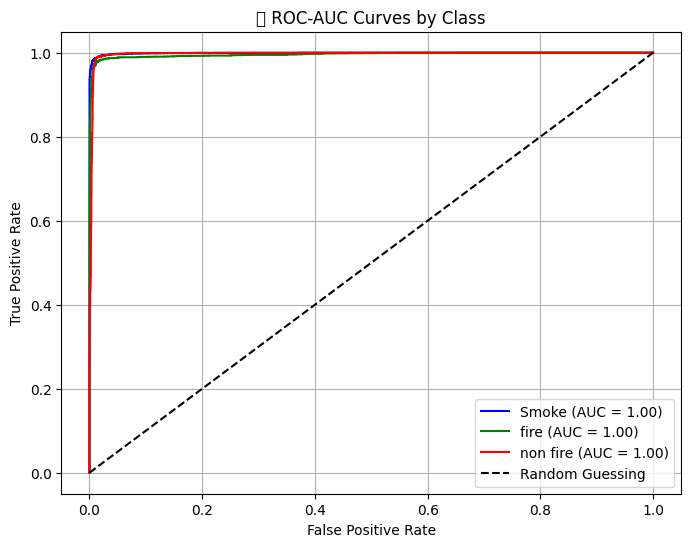

In [7]:
from sklearn.metrics import auc

fpr = {}
tpr = {}
roc_auc = {}
class_names = list(test_data.class_indices.keys())

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_categorical[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC AUC
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']

for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📊 ROC-AUC Curves by Class')
plt.legend()
plt.grid(True)
plt.show()

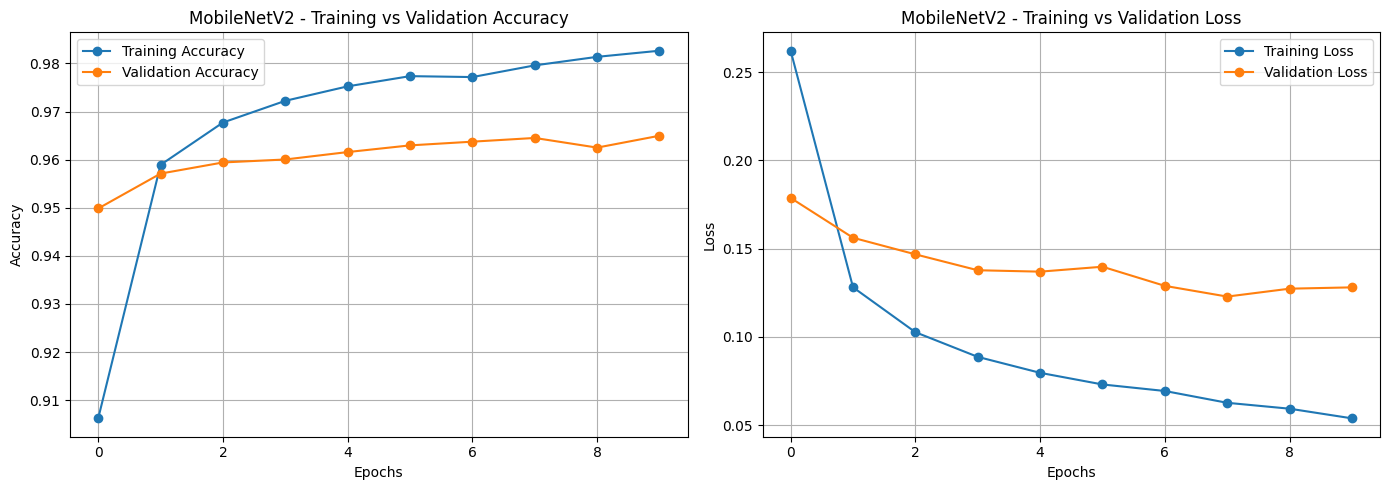

In [8]:
# Plot Accuracy and Loss (Training + Validation)
def plot_training_metrics(history, title_prefix="MobileNetV2"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', marker='o')
    plt.plot(val_acc, label='Validation Accuracy', marker='o')
    plt.title(f'{title_prefix} - Training vs Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', marker='o')
    plt.plot(val_loss, label='Validation Loss', marker='o')
    plt.title(f'{title_prefix} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Use this with your latest training history
plot_training_metrics(history_mobilenet)